## Zooming In + Blur To Simulate DeepthWiseConv2D:
If you zoom-in (enlarge the digit) and then blur it, you are effectively performing "Data Dilation."

Here is how that compares to the DepthwiseConv2D layer in your model:

### The "Thick Line" Simulation
When you zoom-in + blur in preprocessing, you are manually creating a "Bold" version of the digit.

#### Zoom-in:
Stretches the digit, making the strokes physically occupy more pixels.

#### Blur:
Softens the edges of those stretched strokes, making them look like they were written with a thicker marker or a felt-tip pen.

### Does this "Simulate" the DepthwiseConv2D?
In a way, yes, but at a different "resolution" of the logic:

#### Pre-processing (Zoom-In + Blur):
Makes the input more robust. It tells the model: "A '1' is still a '1' even if the person used a thick marker." It helps the first layer of the CNN capture features more easily because there is "more" signal to grab onto.

#### Model Layer (DepthwiseConv2D):
Makes the internal features more robust. It tells the model: "I don't care exactly which pixel this edge is on, just that an edge exists in this general area."

### The Synergy (How they work together)
If you use both, you create a very "stable" vision system:

The Pre-processing ensures the lines are never too thin for the first Conv2D filters to "miss."

The DepthwiseConv2D ensures that as the signal travels deeper into the network and gets smaller (via Pooling), the "thickness" or "presence" of that line isn't lost due to mathematical sampling errors (aliasing).

| Action | Result on Line | Benefit |
| :--- | :--- | :--- |
| **Zoom-In + Blur** | Physical Thickness | Prevents "Empty" filters in the first layer; simulates different pens. |
| **DepthwiseConv2D** | Feature Persistence | Prevents the line from "flickering" or disappearing during downsampling. |

## Why this works for your goals:
CenterCrop + Resizing: By cropping the outer 4 pixels and resizing that 24x24 area back up to 28x28, the digit physically expands. This makes the strokes wider and closer to the edges, simulating a "Zoom-In."

### Depthwise Blur: 
Applying the blur after the resize ensures that the now-larger strokes have soft, anti-aliased edges. This prevents the "pixelated" look that sometimes occurs when upscaling low-resolution images.

### Fixed Logic: 
Because trainable=False, this isn't "learning" to blur; it’s a deterministic mathematical transformation of the input.

## Important Note on Normalization
Since you are changing the input pixels (making them "spread" more), you should re-run the norm_layer.adapt() step using the output of this new preprocessing head to ensure the mean and variance are still accurate for the model.


# Making Convolutional Networks Shift-Invariant Again

| Feature | Zhang (2019) Recommendation | Your Implementation (BlurPooling.txt) |
| :--- | :--- | :--- |
| **Filter Placement** | Directly before any subsampling layer. | Applied before MaxPooling2D in Blocks 1 and 2. |
| **Filter Type** | Fixed (non-trainable) binomial kernels. | `trainable=False` with constant binomial weights. |
| **Operation** | DepthwiseConv2D for efficiency. | Used DepthwiseConv2D to process channels independently. |
| **Kernel Size** | 3x3 or 5x5 filters. | Implemented as a 3x3 kernel. |

# Reference:
1. Gemini: https://gemini.google.com/share/75b200e41b27
2. Making Convolutional Networks Shift-Invariant Again (2019) Richard Zhang
3. Goolge Colab Version of this notebook: https://colab.research.google.com/drive/1i3HBuY11yksRTB3Oa-PaGQ3__15zgmhq#scrollTo=b30594bc

2026-03-12 11:03:55.941749: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773313436.211766      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773313436.278215      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773313436.864909      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773313436.864959      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773313436.864962      17 computation_placer.cc:177] computation placer alr

--- Loading EMNIST Digits from local PNG folders ---
Found 240000 files belonging to 10 classes.
Using 192000 files for training.


2026-03-12 11:09:42.230879: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 240000 files belonging to 10 classes.
Using 48000 files for validation.
Found 40000 files belonging to 10 classes.
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


Model: "VGG_Bin5_EMNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessing_head (Sequential) │ (None, 28, 28, 1)      │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn1 (BatchNormalization) │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn2 (BatchNormalization) │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_relu2 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_blur (DepthwiseConv2D)   │ (None, 28, 28, 32)     │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn1 (BatchNormalization) │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn2 (BatchNormalization) │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_relu2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_blur (DepthwiseConv2D)   │ (None, 14, 14, 64)     │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn1 (BatchNormalization) │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu1 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn2 (BatchNormalization) │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_relu2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 7, 7, 128)      │       147,58

 Total params: 740,685 (2.83 MB)

 Trainable params: 733,418 (2.80 MB)

 Non-trainable params: 7,267 (28.39 KB)

Epoch 1/250
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9718 - loss: 0.2506
Epoch 1: val_accuracy improved from -inf to 0.98577, saving model to emnist_best_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1005s 477ms/step - accuracy: 0.9718 - loss: 0.2506 - val_accuracy: 0.9858 - val_loss: 0.1458 - learning_rate: 0.0010
Epoch 2/250
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9918 - loss: 0.1112
Epoch 2: val_accuracy did not improve from 0.98577
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1236s 776ms/step - accuracy: 0.9918 - loss: 0.1112 - val_accuracy: 0.9770 - val_loss: 0.1285 - learning_rate: 0.0010
Epoch 3/250
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.9921 - loss: 0.0801
Epoch 3: val_accuracy improved from 0.98577 to 0.98765, saving model to emnist_best_model.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1944s 462ms/step - accuracy: 0.9921 - loss: 0.0801 - val_accuracy: 0.9876 - val_loss: 0.0862 - learning_rate: 0.0010
Epoch 4/250
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 

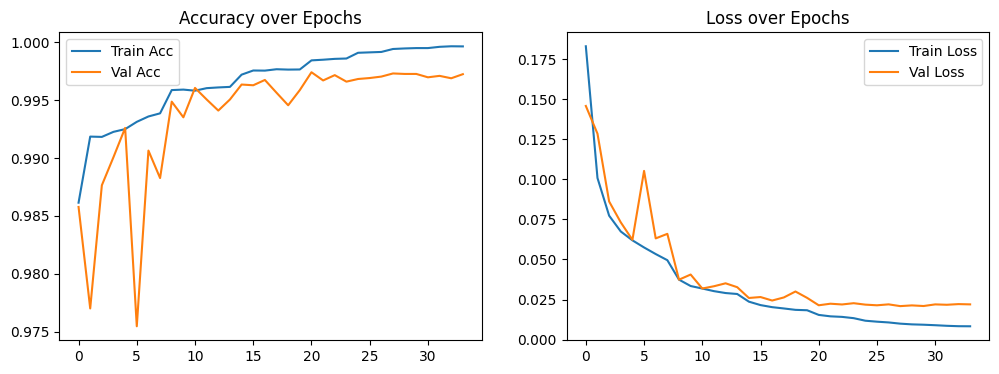

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4000
           1       1.00      1.00      1.00      4000
           2       1.00      1.00      1.00      4000
           3       1.00      1.00      1.00      4000
           4       1.00      1.00      1.00      4000
           5       1.00      1.00      1.00      4000
           6       1.00      1.00      1.00      4000
           7       1.00      1.00      1.00      4000
           8       1.00      1.00      1.00      4000
           9       1.00      1.00      1.00      4000

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000


Accuracy (Test Set): 0.9973


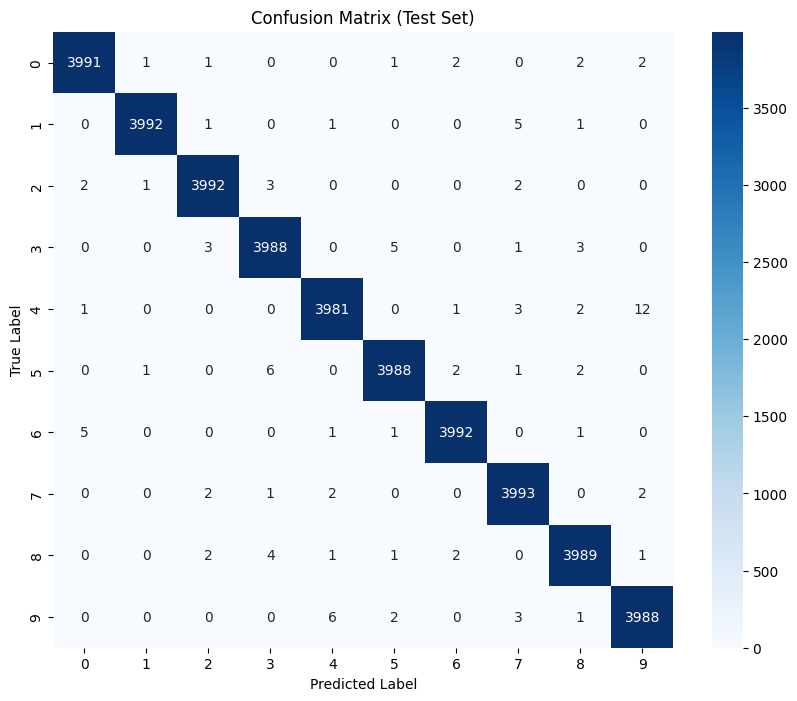

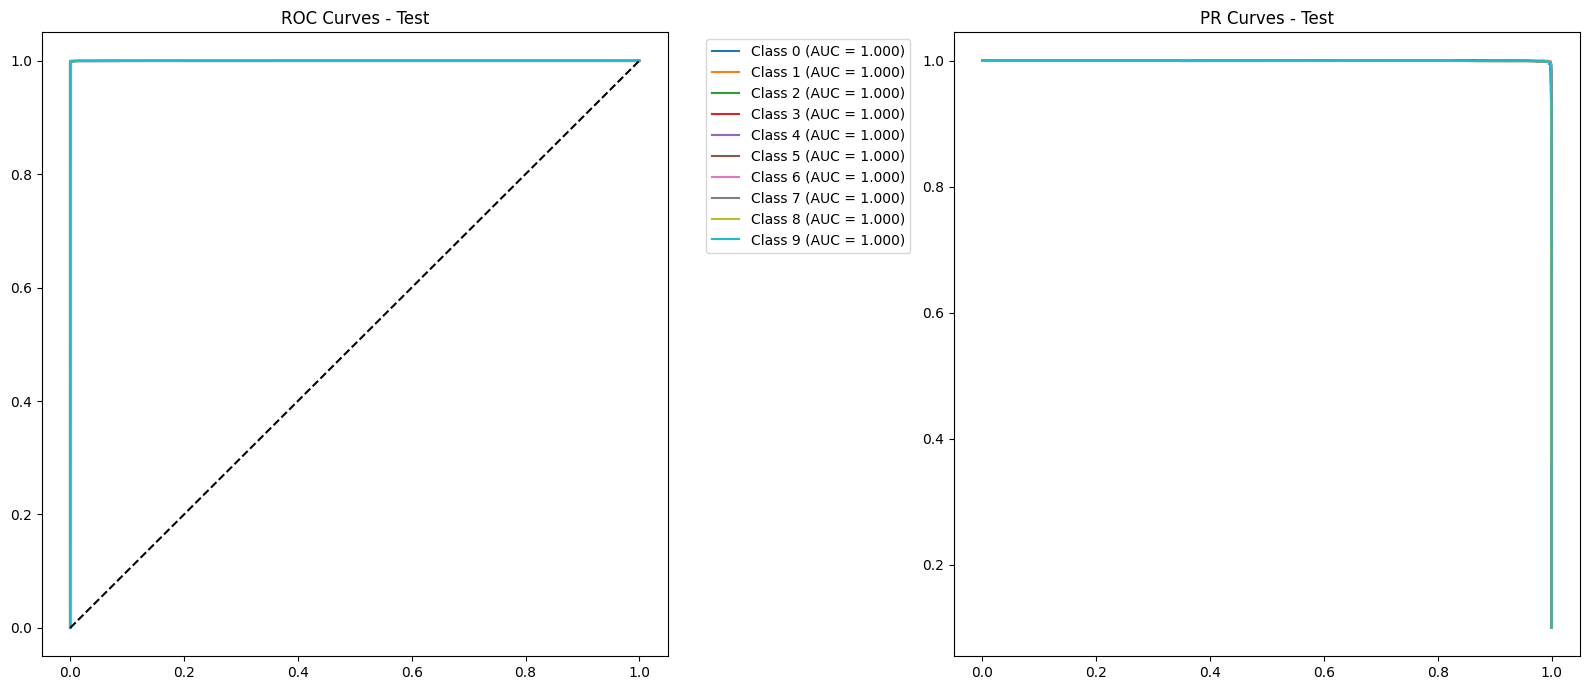

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.metrics import (roc_curve, auc, precision_recall_curve, 
                             average_precision_score, confusion_matrix, 
                             classification_report, accuracy_score)
from sklearn.preprocessing import label_binarize


# Download latest version
DATA_DIR = "/kaggle/input/emnist-digits-balanced"

def get_keras_dataset():
    print("--- Loading EMNIST Digits from local PNG folders ---")

    # Global access and constants
    IMG_SIZE = (28, 28)
    BATCH_SIZE = 128
    SEED = 42

    # 1. Load TRAIN dataset
    train_ds = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_DIR}/train",
        validation_split=0.2,
        subset="training",
        seed=SEED,
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    val_ds = tf.keras.utils.image_dataset_from_directory(
        f"{DATA_DIR}/train",
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE
    )

    # 2. Load TEST dataset
    test_ds = tf.keras.utils.image_dataset_from_directory(
        directory=f"{DATA_DIR}/test",
        labels="inferred",
        label_mode="int",
        color_mode="grayscale",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    class_names = train_ds.class_names
    print("Class names:", class_names)

    # 4. Normalization layer (NO augmentation)
    norm_layer = layers.Normalization(axis=None)
    # Adapt on a mapping to ensure the stats are based on [0, 1] range
    norm_layer.adapt(
        train_ds.map(lambda x, y: x / 255.0).take(500)
    )

    preprocessing_model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Rescaling(1./255),
        norm_layer
    ], name="preprocessing_head")

    # 5. Final pipeline
    def finalize(ds, shuffle=False):
        if shuffle:
            ds = ds.shuffle(10000, seed=SEED)
        return ds.prefetch(tf.data.AUTOTUNE)

    train_ds = finalize(train_ds, shuffle=True)
    val_ds = finalize(val_ds)
    test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds, preprocessing_model


def build_vgg_blur_bin5(preprocessing_layer):
    l2_reg = regularizers.l2(1e-4)
    
    # 1. Define Binomial-5 Kernel (Outer product of [1, 4, 6, 4, 1])
    v = np.array([1, 4, 6, 4, 1], dtype='float32')
    kernel_5x5 = np.outer(v, v)
    kernel_5x5 /= kernel_5x5.sum()

    # 2. Weight helper for DepthwiseConv2D
    def get_bin5_weights(channels):
        w = np.zeros((5, 5, channels, 1), dtype='float32')
        for i in range(channels):
            w[:, :, i, 0] = kernel_5x5
        return w

    # 3. Helper to build a VGG block with BlurPooling
    def vgg_block(x, filters, num_convs, block_id):
        for i in range(num_convs):
            x = layers.Conv2D(filters, (3, 3), padding='same', 
                              kernel_initializer='he_normal', 
                              kernel_regularizer=l2_reg,
                              name=f'block{block_id}_conv{i+1}')(x)
            x = layers.BatchNormalization(name=f'block{block_id}_bn{i+1}')(x)
            x = layers.Activation('relu', name=f'block{block_id}_relu{i+1}')(x)
        
        # Insert Bin-5 Blur before MaxPooling
        x = layers.DepthwiseConv2D(kernel_size=5, strides=1, padding='same', use_bias=False,
                                   depthwise_initializer=tf.keras.initializers.Constant(get_bin5_weights(filters)),
                                   trainable=False,
                                   name=f'block{block_id}_blur')(x)
        x = layers.MaxPooling2D(pool_size=(2, 2), name=f'block{block_id}_pool')(x)
        return x

    # --- Construct Model ---
    inputs = layers.Input(shape=(28, 28, 1))
    x = preprocessing_layer(inputs)

    # VGG Configuration: (filters, num_convs)
    # Using 3 blocks for EMNIST (28->14->7->3)
    x = vgg_block(x, 32,  num_convs=2, block_id=1)
    x = vgg_block(x, 64, num_convs=2, block_id=2)
    x = vgg_block(x, 128, num_convs=3, block_id=3)

    # Classification Head
    x = layers.Flatten()(x)
    x = layers.Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2_reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="VGG_Bin5_EMNIST")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


# Initialize
train_data, val_data, test_data, prep_layer = get_keras_dataset()
model = build_vgg_blur_bin5(prep_layer)
model.summary()


# Callbacks
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
checkpoint = callbacks.ModelCheckpoint("emnist_best_model.keras", monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

# Train
history = model.fit(
    train_data,
    epochs=250,
    validation_data=val_data,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# Plotting
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

# Evaluation logic
def get_actual_and_probabilities(dataset):
    y_true = []
    y_probs = []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_probs.extend(preds)
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_probs)

def plot_evaluation_curves(y_true_labels, y_probs, class_names, set_name="Test"):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true_labels, classes=range(n_classes))
    
    plt.figure(figsize=(16, 7))
    plt.subplot(1, 2, 1)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        plt.plot(fpr, tpr, label=f'Class {class_names[i]} (AUC = {auc(fpr, tpr):.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curves - {set_name}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.subplot(1, 2, 2)
    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_probs[:, i])
        plt.plot(recall, precision, label=f'Class {class_names[i]}')
    plt.title(f'PR Curves - {set_name}')
    plt.tight_layout()
    plt.show()

# Final Evaluation
target_names = [str(i) for i in range(10)]
y_test_true, y_test_probs = get_actual_and_probabilities(test_data)

# Get predicted labels for the test set
y_test_pred = np.argmax(y_test_probs, axis=1)

# 1. Print classification report
print("Classification Report (Test Set):")
print(classification_report(y_test_true, y_test_pred, target_names=target_names))

# 2. Print accuracy on test set
accuracy = accuracy_score(y_test_true, y_test_pred)
print(f"\nAccuracy (Test Set): {accuracy:.4f}")

# 3. Plot confusion matrix for test set
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test_true, y_test_pred),
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

plot_evaluation_curves(y_test_true, y_test_probs, target_names, set_name="Test")